<a href="https://colab.research.google.com/github/lizagrin/AVPersonTraits-BigFive/blob/main/notebooks/FIv2_VSSD_full_end2end_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIv2 + VSSD: full multimodal training notebook

Этот ноутбук собран под задачу **аудиовизуальной оценки Big Five** на **First Impressions V2** с опорой на **VSSD** как визуальный backbone.

## Что внутри
- загрузка датасета из **Hugging Face** или работа с локальной копией
- извлечение и кэширование лиц и аудио
- официальный **VSSD-Small / VSSD-Tiny** как visual encoder
- сильная мультимодальная архитектура:
  - VSSD per frame
  - attention pooling по кадрам внутри окна
  - BiGRU + self-attention по окнам
  - deep audio branch по log-mel
  - hand-crafted audio branch по prosody / eGeMAPS
  - **trait-wise late fusion** на уровне прогнозов
- обучение с лоссами:
  - Huber
  - CCC
  - bin classification
  - batchwise pairwise / ranking loss
- staged unfreezing
- валидация по **MAE / mACC / CCC**
- сохранение чекпоинтов и предсказаний

## Главное
Ноутбук рассчитан на режим, где у вас реально много GPU-памяти и вы хотите **сильную end-to-end систему**, а не упрощённый baseline.

In [1]:
!pip uninstall -y pillow PIL opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless >/dev/null 2>&1

!pip install -U pip setuptools wheel
!pip install --no-cache-dir --force-reinstall pillow "jedi>=0.18"
!pip install -q fvcore iopath
# Выбери РОВНО ОДИН пакет OpenCV:
!pip install --no-cache-dir "opencv-python-headless<4.12"
# если нужны contrib-модули, вместо строки выше:
# !pip install --no-cache-dir "opencv-contrib-python-headless<4.12"

!python -m pip check

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 144.8 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires pillow>=9.0.0, which is not installed.
torchvision 0.25.0+cu128 requires pillow!=8.3.*,>=5.3.0, which is not installed.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 179.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 548.7 MB/s  0:00:00
  Attempting uninstall: parso
    Found existing installation: parso 0.8.6
    Uninstalling parso-0.8.6:
      Successfully uninstalled parso-0.8.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [jedi]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 99.3 MB/s  0:00:00
dopamine-rl 4.1.2 requires opencv-python, which is not installed.
gradio 5.50.0 has requirement pillow<12.0,>=8.0, but you have pillow 12.2.0.


In [2]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))

x = torch.randn(2, 3, 224, 224, device="cuda")
print("cuda tensor ok:", x.shape, x.device)

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
device: NVIDIA RTX PRO 6000 Blackwell Server Edition
capability: (12, 0)
cuda tensor ok: torch.Size([2, 3, 224, 224]) cuda:0


In [3]:
import os
os.environ["MAX_JOBS"] = "4"

In [ ]:
!pip install -v --no-build-isolation "causal-conv1d>=1.4.0"
!pip install -v --no-build-isolation "mamba-ssm>=2.2.2"

Using pip 26.0.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Running command Preparing metadata (pyproject.toml)
  /usr/local/lib/python3.12/dist-packages/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
    warn(
  /usr/local/lib/python3.12/dist-packages/setuptools/dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
  !!

          ********************************************************************************
          Please consider removing the following classifiers in favor of a SPDX license expression:

          License :: OSI Approved :: BSD License

          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************

In [ ]:
!pip uninstall -y mamba-ssm causal-conv1d
!MAMBA_FORCE_BUILD=TRUE pip install -v --no-cache-dir --no-build-isolation git+https://github.com/state-spaces/mamba.git

torch: 2.2.2+cu121
torchvision: 0.17.2+cu121
torchaudio: 2.2.2+cu121
cuda available: True
opencv: 4.11.0
numpy: 1.26.4


In [ ]:
import torch
import mamba_ssm
from mamba_ssm.ops.triton.ssd_combined import (
    mamba_chunk_scan_combined,
    mamba_split_conv1d_scan_combined,
)
from mamba_ssm.ops.triton.layernorm_gated import RMSNorm as RMSNormGated
from mamba_ssm.ops.triton.selective_state_update import selective_state_update

print("mamba_ssm imported successfully")
print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)

mamba_ssm imported successfully
torch: 2.11.0+cu128
cuda: 12.8


In [ ]:
import os
import gc
import cv2
import sys
import math
import time
import json
import glob
import yaml
import shutil
import random
import pickle
import warnings
import argparse
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, DatasetDict, Video
from huggingface_hub import snapshot_download, hf_hub_download

import librosa
import soundfile as sf
import opensmile

from decord import VideoReader, cpu
from facenet_pytorch import MTCNN

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("high")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

DEVICE: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM GB: 94.97


## Конфиг

Ниже значения уже подобраны под **сильный режим**, а не под минимальную экономию ресурсов.

In [ ]:
@dataclass
class CFG:
    # paths
    project_root: str = "/content/fiv2_vssd_project"
    dataset_source: str = "hf"           # "hf" или "local"
    hf_dataset_repo: str = "yeray142/first-impressions-v2"
    local_dataset_root: str = "/content/first-impressions-v2"
    hf_snapshot_dir: str = "/content/first-impressions-v2-snapshot"
    cache_root: str = "/content/fiv2_cache"
    checkpoints_dir: str = "/content/fiv2_checkpoints"
    logs_dir: str = "/content/fiv2_logs"
    vssd_repo_dir: str = "/content/VSSD"

    # data
    train_windows: int = 8
    eval_windows: int = 12
    train_frames_per_window: int = 4
    eval_frames_per_window: int = 6
    local_window_span_sec: float = 2.0
    face_size: int = 224
    sample_rate: int = 16000

    # audio
    n_mels: int = 128
    n_fft: int = 1024
    hop_length: int = 320
    win_length: int = 1024
    use_ege_maps: bool = True

    # model
    trait_names: Tuple[str, ...] = ("openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism")
    num_traits: int = 5
    num_bins: int = 3

    vssd_variant: str = "small"          # "tiny" or "small"
    vssd_ckpt_repo: str = "YuhengSSS/VSSD_ICCV_weights"
    vssd_small_ckpt: str = "vssd_small_mesa.pth"
    vssd_tiny_ckpt: str = "vssd_tiny_mesa.pth"

    hidden_dim: int = 512
    temporal_dim: int = 512
    audio_deep_dim: int = 256
    audio_hc_dim: int = 128
    dropout: float = 0.15
    modality_dropout_p: float = 0.10

    # ---------------- optimization ----------------
    batch_size: int = 2
    eval_batch_size: int = 2
    num_workers: int = 4
    weight_decay: float = 1e-4
    amp: bool = True
    grad_accum_steps: int = 2
    max_grad_norm: float = 1.0

    # staged training
    stage1_epochs: int = 2   # frozen VSSD
    stage2_epochs: int = 4   # unfreeze last VSSD stage
    stage3_epochs: int = 6   # unfreeze all VSSD

    lr_heads_stage1: float = 3e-4
    lr_heads_stage2: float = 1.5e-4
    lr_heads_stage3: float = 8e-5

    lr_backbone_stage2: float = 8e-6
    lr_backbone_stage3: float = 3e-6

    # ---------------- losses ----------------
    lambda_ccc: float = 0.5
    lambda_bin: float = 0.2
    lambda_pair: float = 0.1
    lambda_aux_modal: float = 0.15
    huber_beta: float = 0.05

    # ---------------- misc ----------------
    max_train_samples: Optional[int] = None
    max_val_samples: Optional[int] = None
    use_compile: bool = False
    save_every_epoch: bool = True

cfg = CFG()

for p in [cfg.project_root, cfg.cache_root, cfg.checkpoints_dir, cfg.logs_dir]:
    os.makedirs(p, exist_ok=True)

print(asdict(cfg))

{'project_root': '/content/fiv2_vssd_project', 'dataset_source': 'hf', 'hf_dataset_repo': 'yeray142/first-impressions-v2', 'local_dataset_root': '/content/first-impressions-v2', 'hf_snapshot_dir': '/content/first-impressions-v2-snapshot', 'cache_root': '/content/fiv2_cache', 'checkpoints_dir': '/content/fiv2_checkpoints', 'logs_dir': '/content/fiv2_logs', 'vssd_repo_dir': '/content/VSSD', 'train_windows': 8, 'eval_windows': 12, 'train_frames_per_window': 4, 'eval_frames_per_window': 6, 'local_window_span_sec': 2.0, 'face_size': 224, 'sample_rate': 16000, 'n_mels': 128, 'n_fft': 1024, 'hop_length': 320, 'win_length': 1024, 'use_ege_maps': True, 'trait_names': ('openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism'), 'num_traits': 5, 'num_bins': 3, 'vssd_variant': 'small', 'vssd_ckpt_repo': 'YuhengSSS/VSSD_ICCV_weights', 'vssd_small_ckpt': 'vssd_small_mesa.pth', 'vssd_tiny_ckpt': 'vssd_tiny_mesa.pth', 'hidden_dim': 512, 'temporal_dim': 512, 'audio_deep_dim': 256,

## Датасет: загрузка из локальной копии


In [ ]:
TRAIT_CANDIDATES = {
    "openness": ["openness", "Openness", "O", "imaginative"],
    "conscientiousness": ["conscientiousness", "Conscientiousness", "C", "organized"],
    "extraversion": ["extraversion", "Extraversion", "E", "friendly"],
    "agreeableness": ["agreeableness", "Agreeableness", "A", "authentic"],
    "neuroticism": ["neuroticism", "Neuroticism", "N"],
    "interview": ["interview", "Interview"]
}
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import pickle
from pathlib import Path
import pandas as pd

DRIVE_ROOT = "/content/drive/MyDrive/FIv2_persistent_cache"
DATA_ROOT = f"{DRIVE_ROOT}/DATA"

TRAIN_DIR = f"{DATA_ROOT}/TRAIN"
VAL_DIR = f"{DATA_ROOT}/VALIDATION"
TEST_DIR = f"{DATA_ROOT}/TEST"

PROJECT_CACHE_DIR = f"{DRIVE_ROOT}/project_cache"
CHECKPOINTS_DIR = f"{DRIVE_ROOT}/checkpoints"
LOGS_DIR = f"{DRIVE_ROOT}/logs"

os.makedirs(PROJECT_CACHE_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

# 2. ОБНОВЛЯЕМ CFG

cfg.dataset_source = "local"
cfg.local_dataset_root = DATA_ROOT
cfg.cache_root = PROJECT_CACHE_DIR
cfg.checkpoints_dir = CHECKPOINTS_DIR
cfg.logs_dir = LOGS_DIR

print("cfg.local_dataset_root =", cfg.local_dataset_root)
print("cfg.cache_root =", cfg.cache_root)
print("cfg.checkpoints_dir =", cfg.checkpoints_dir)
print("cfg.logs_dir =", cfg.logs_dir)

# 3. ЗАГРУЗКА PICKLE

def load_pickle_compat(path):
    with open(path, "rb") as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            return pickle.load(f, encoding="latin1")

# 4. ПУТИ К ФАЙЛАМ SPLIT

def get_split_paths(root, split):
    split_map = {
        "train": {
            "dir": "TRAIN",
            "ann": "annotation_training.pkl",
            "tr": "transcription_training.pkl",
        },
        "validation": {
            "dir": "VALIDATION",
            "ann": "annotation_validation.pkl",
            "tr": "transcription_validation.pkl",
        },
        "test": {
            "dir": "TEST",
            "ann": "annotation_test.pkl",
            "tr": "transcription_test.pkl",
        },
    }

    spec = split_map[split]
    split_dir = os.path.join(root, spec["dir"])
    ann_path = os.path.join(split_dir, "Annotation", spec["ann"])
    tr_path = os.path.join(split_dir, "Annotation", spec["tr"])

    if not os.path.exists(ann_path):
        raise FileNotFoundError(f"Не найден файл аннотаций: {ann_path}")

    if not os.path.exists(tr_path):
        tr_path = None

    return split_dir, ann_path, tr_path
# 5. КЛЮЧИ В PKL

def possible_video_keys(video_name):
    stem = Path(video_name).stem
    fname = Path(video_name).name
    return [stem, fname]

def get_by_video_name(mapping, video_name):
    if not isinstance(mapping, dict):
        return None

    for key in possible_video_keys(video_name):
        if key in mapping:
            return mapping[key]

    return None

def get_trait_value(annotation_obj, trait_name, video_name):
    if not isinstance(annotation_obj, dict):
        return None
    if trait_name not in annotation_obj:
        return None
    return get_by_video_name(annotation_obj[trait_name], video_name)

def get_transcription_value(transcription_obj, video_name):
    if transcription_obj is None:
        return ""

    if isinstance(transcription_obj, dict):
        val = get_by_video_name(transcription_obj, video_name)
        if val is not None:
            return val if isinstance(val, str) else str(val)

        if "transcription" in transcription_obj and isinstance(transcription_obj["transcription"], dict):
            val = get_by_video_name(transcription_obj["transcription"], video_name)
            if val is not None:
                return val if isinstance(val, str) else str(val)

    return ""

# 6. СБОР MANIFEST
def build_manifest_from_local(root):
    manifests = {}

    for split in ["train", "validation", "test"]:
        split_dir, ann_path, tr_path = get_split_paths(root, split)

        ann = load_pickle_compat(ann_path)
        tr = load_pickle_compat(tr_path) if tr_path is not None else None

        video_files = []
        for ext in ["*.mp4", "*.avi", "*.mov", "*.mkv", "*.webm"]:
            video_files.extend(glob.glob(os.path.join(split_dir, ext)))

        rows = []
        skipped = 0

        for video_path in sorted(video_files):
            video_name = os.path.basename(video_path)
            video_id = Path(video_path).stem

            row = {
                "split": split,
                "video_id": video_id,
                "video_path": video_path,
                "age_group": None,
                "transcription": get_transcription_value(tr, video_name),
            }

            ok = True
            for trait in cfg.trait_names:
                value = get_trait_value(ann, trait, video_name)
                if value is None:
                    ok = False
                    break
                row[trait] = float(value)

            if ok:
                rows.append(row)
            else:
                skipped += 1

        manifests[split] = pd.DataFrame(rows)
        print(f"{split}: {manifests[split].shape}, skipped={skipped}")

    return manifests
# 7. СТРОИМ SPLIT-ТАБЛИЦЫ

manifests = build_manifest_from_local(cfg.local_dataset_root)

train_manifest = manifests["train"].copy()
val_manifest = manifests["validation"].copy()
test_manifest = manifests["test"].copy()

if cfg.max_train_samples is not None:
    train_manifest = train_manifest.sample(
        min(cfg.max_train_samples, len(train_manifest)),
        random_state=SEED
    ).reset_index(drop=True)

if cfg.max_val_samples is not None:
    val_manifest = val_manifest.sample(
        min(cfg.max_val_samples, len(val_manifest)),
        random_state=SEED
    ).reset_index(drop=True)

print("train:", train_manifest.shape)
print("val:", val_manifest.shape)
print("test:", test_manifest.shape)

display(train_manifest.head())

# 8. СОХРАНЯЕМ MANIFEST

train_manifest.to_csv(f"{DRIVE_ROOT}/train_manifest.csv", index=False)
val_manifest.to_csv(f"{DRIVE_ROOT}/val_manifest.csv", index=False)
test_manifest.to_csv(f"{DRIVE_ROOT}/test_manifest.csv", index=False)

print("Manifest files saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cfg.local_dataset_root = /content/drive/MyDrive/FIv2_persistent_cache/DATA
cfg.cache_root = /content/drive/MyDrive/FIv2_persistent_cache/project_cache
cfg.checkpoints_dir = /content/drive/MyDrive/FIv2_persistent_cache/checkpoints
cfg.logs_dir = /content/drive/MyDrive/FIv2_persistent_cache/logs
train: (6000, 10), skipped=0
validation: (2000, 10), skipped=0
test: (2000, 10), skipped=0
train: (6000, 10)
val: (2000, 10)
test: (2000, 10)


,split,video_id,video_path,age_group,transcription,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,train,--Ymqszjv54.001,/content/drive/MyDrive/FIv2_persistent_cache/D...,None,I like Tabasco sauce. I like Louisiana Hot Sau...,0.744444,0.650485,0.551402,0.527473,0.500000
1,train,--Ymqszjv54.003,/content/drive/MyDrive/FIv2_persistent_cache/D...,None,Lot more things there. Then the menus are a lo...,0.466667,0.475728,0.392523,0.516484,0.427083
2,train,--Ymqszjv54.004,/content/drive/MyDrive/FIv2_persistent_cache/D...,None,There you go and red. See? [yelling 00:00:04]....,0.544444,0.368932,0.317757,0.549451,0.322917
3,train,--Ymqszjv54.005,/content/drive/MyDrive/FIv2_persistent_cache/D...,None,This doesn't have a name on it. This is from O...,0.344444,0.320388,0.299065,0.373626,0.291667
4,train,-2qsCrkXdWs.001,/content/drive/MyDrive/FIv2_persistent_cache/D...,None,I'm thinking with how much time and energy I'm...,0.611111,0.572816,0.476636,0.593407,0.604167


Manifest files saved to Drive.


## Предобработка и кэширование

Кэш на диск нужен обязательно. Иначе обучение будет упираться в face detection и декодирование видео, а не в модель.

In [ ]:
cfg.cache_root = "/content/drive/MyDrive/FIv2_persistent_cache/project_cache"
MEL_CACHE_DIR = os.path.join(cfg.cache_root, "mel")
VIDEO_CACHE_DIR = os.path.join(cfg.cache_root, "video")
AUDIO_CACHE_DIR = os.path.join(cfg.cache_root, "audio")
for p in [MEL_CACHE_DIR, VIDEO_CACHE_DIR, AUDIO_CACHE_DIR]:
    os.makedirs(p, exist_ok=True)

mtcnn = MTCNN(
    image_size=cfg.face_size,
    margin=12,
    keep_all=False,
    post_process=False,
    device=DEVICE
)

smile = None
if cfg.use_ege_maps:
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals,
    )

def safe_video_reader(video_path):
    try:
        vr = VideoReader(video_path, ctx=cpu(0))
        return vr
    except Exception as e:
        print(f"Video open error: {video_path} -> {e}")
        return None

def seconds_to_idx(sec, fps, n_frames):
    idx = int(round(sec * fps))
    return max(0, min(n_frames - 1, idx))

def sample_window_centers(duration_sec, n_windows):
    if n_windows <= 1:
        return [duration_sec / 2.0]
    left = 0.75
    right = max(left, duration_sec - 0.75)
    return np.linspace(left, right, n_windows).tolist()

def sample_times_around(center_sec, span_sec, n_frames):
    start = max(0.0, center_sec - span_sec / 2)
    end = center_sec + span_sec / 2
    return np.linspace(start, end, n_frames).tolist()

def detect_face_or_center(frame_rgb):
    try:
        out = mtcnn(frame_rgb)
        if out is not None:
            x = out.permute(1, 2, 0).cpu().numpy()
            x = np.clip(x, 0, 255).astype(np.uint8)
            return x, 1.0
    except Exception:
        pass

    h, w = frame_rgb.shape[:2]
    s = min(h, w)
    y1 = (h - s) // 2
    x1 = (w - s) // 2
    crop = frame_rgb[y1:y1+s, x1:x1+s]
    crop = cv2.resize(crop, (cfg.face_size, cfg.face_size))
    return crop, 0.0

def load_audio_from_video(video_path, sample_rate=16000):
    wav_path = os.path.join(AUDIO_CACHE_DIR, Path(video_path).stem + ".wav")
    if not os.path.exists(wav_path):
        cmd = f'ffmpeg -y -i "{video_path}" -ac 1 -ar {sample_rate} "{wav_path}" -loglevel error'
        os.system(cmd)
    y, sr = librosa.load(wav_path, sr=sample_rate, mono=True)
    return y, sr, wav_path

def make_logmel(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=cfg.n_mels,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        win_length=cfg.win_length,
        power=2.0,
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    return mel.astype(np.float32)

def make_basic_prosody(y, sr):
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    try:
        f0 = librosa.yin(y, fmin=50, fmax=400, sr=sr)
    except Exception:
        f0 = np.zeros_like(rms)

    feats = []
    for arr in [rms, zcr, f0]:
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        feats.extend([arr.mean(), arr.std(), np.median(arr), arr.min(), arr.max()])

    mfcc = np.nan_to_num(mfcc, nan=0.0, posinf=0.0, neginf=0.0)
    feats.extend(mfcc.mean(axis=1).tolist())
    feats.extend(mfcc.std(axis=1).tolist())
    return np.array(feats, dtype=np.float32)

def make_ege_maps(wav_path):
    if smile is None:
        return None
    try:
        df = smile.process_file(wav_path)
        return df.iloc[0].values.astype(np.float32)
    except Exception:
        return None

def get_cache_path(split, video_id):
    folder = os.path.join(VIDEO_CACHE_DIR, split)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, video_id + ".pt")

def preprocess_and_cache_video(row, train_mode=True, overwrite=False):
    split = row["split"]
    video_id = row["video_id"]
    video_path = row["video_path"]

    cache_path = get_cache_path(split, video_id)
    if os.path.exists(cache_path) and not overwrite:
        return cache_path

    n_windows = cfg.train_windows if train_mode else cfg.eval_windows
    k_frames = cfg.train_frames_per_window if train_mode else cfg.eval_frames_per_window

    vr = safe_video_reader(video_path)
    if vr is None:
        return None

    n_frames_total = len(vr)
    if n_frames_total == 0:
        return None

    fps = float(vr.get_avg_fps()) if hasattr(vr, "get_avg_fps") else 25.0
    duration_sec = n_frames_total / max(fps, 1e-6)

    centers = sample_window_centers(duration_sec, n_windows)
    all_faces = []
    all_scores = []

    for c in centers:
        times = sample_times_around(c, cfg.local_window_span_sec, k_frames)
        faces = []
        scores = []
        for t in times:
            idx = seconds_to_idx(t, fps, n_frames_total)
            frame = vr[idx].asnumpy()
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            face, score = detect_face_or_center(frame_rgb)
            faces.append(face)
            scores.append(score)
        all_faces.append(np.stack(faces))
        all_scores.append(np.array(scores, dtype=np.float32))

    y, sr, wav_path = load_audio_from_video(video_path, sample_rate=cfg.sample_rate)
    mel = make_logmel(y, sr)
    prosody = make_basic_prosody(y, sr)
    ege = make_ege_maps(wav_path)

    target = np.array([row[t] for t in cfg.trait_names], dtype=np.float32)

    payload = {
        "video_id": video_id,
        "video_path": video_path,
        "split": split,
        "faces": np.stack(all_faces).astype(np.uint8),
        "face_scores": np.stack(all_scores).astype(np.float32),
        "mel": mel.astype(np.float32),
        "prosody": prosody.astype(np.float32),
        "ege_maps": ege.astype(np.float32) if ege is not None else None,
        "target": target,
        "transcription": row.get("transcription", ""),
    }
    torch.save(payload, cache_path)
    return cache_path

def precache_manifest(manifest, train_mode=True, overwrite=False):
    ok = 0
    for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
        p = preprocess_and_cache_video(row, train_mode=train_mode, overwrite=overwrite)
        ok += int(p is not None)
    print(f"cached {ok}/{len(manifest)}")

In [ ]:
# cfg.cache_root = "/content/fiv2_cache_local"
# # cfg.cache_root = "/content/drive/MyDrive/FIv2_persistent_cache/project_cache"
# MEL_CACHE_DIR = os.path.join(cfg.cache_root, "mel")
# VIDEO_CACHE_DIR = os.path.join(cfg.cache_root, "video")
# AUDIO_CACHE_DIR = os.path.join(cfg.cache_root, "audio")

# for p in [MEL_CACHE_DIR, VIDEO_CACHE_DIR, AUDIO_CACHE_DIR]:
#     os.makedirs(p, exist_ok=True)

# print("Local cache root:", cfg.cache_root)

Local cache root: /content/fiv2_cache_local


In [ ]:
# precache_manifest(train_manifest, train_mode=True, overwrite=False)
# precache_manifest(val_manifest, train_mode=False, overwrite=False)

  0%|          | 0/6000 [00:00<?, ?it/s]

cached 6000/6000


  0%|          | 0/2000 [00:00<?, ?it/s]

cached 2000/2000


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# import subprocess

# SRC = "/content/fiv2_cache_local"
# DST = "/content/drive/MyDrive/FIv2_persistent_cache/project_cache"

# os.makedirs(DST, exist_ok=True)

# cmd = ["rsync", "-ah", "--info=progress2", "--partial", "--append-verify", SRC + "/", DST + "/"]
# print("RUN:", " ".join(cmd))
# subprocess.run(cmd, check=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN: rsync -ah --info=progress2 --partial --append-verify /content/fiv2_cache_local/ /content/drive/MyDrive/FIv2_persistent_cache/project_cache/


CompletedProcess(args=['rsync', '-ah', '--info=progress2', '--partial', '--append-verify', '/content/fiv2_cache_local/', '/content/drive/MyDrive/FIv2_persistent_cache/project_cache/'], returncode=0)

## Подключение официального VSSD

Ниже — реальное использование репозитория VSSD:
- клонирование официального репозитория
- поиск подходящего config yaml
- загрузка pretrained checkpoint
- использование `forward_features(...)` как frame encoder

In [ ]:
%%capture
import os

if not os.path.exists("/content/VSSD"):
    !git clone https://github.com/YuHengsss/VSSD.git /content/VSSD

# Ставим зависимости VSSD, но НЕ трогаем torch/torchvision/torchaudio
!python - <<'PY'
from pathlib import Path

src = Path("/content/VSSD/requirements.txt")
dst = Path("/content/VSSD/requirements_no_torch.txt")

lines = src.read_text().splitlines()
filtered = []
for line in lines:
    s = line.strip()
    if not s:
        continue
    if s.startswith("torch==") or s.startswith("torchvision") or s.startswith("torchaudio"):
        continue
    filtered.append(line)

dst.write_text("\n".join(filtered) + "\n")
print(dst.read_text())

!pip install -q -r /content/VSSD/requirements_no_torch.txt

In [ ]:
from pathlib import Path
import os
import sys
import glob
import argparse

import torch
import torch.nn as nn
from torch.utils import _pytree as torch_pytree

if not hasattr(torch_pytree, "register_pytree_node"):
    def register_pytree_node(cls, flatten_fn, unflatten_fn, *, serialized_type_name=None):
        return
    torch_pytree.register_pytree_node = register_pytree_node

VSSD_CLASSIFICATION_ROOT = Path("/content/VSSD/classification")
assert VSSD_CLASSIFICATION_ROOT.exists(), f"Не найден путь: {VSSD_CLASSIFICATION_ROOT}"

if str(VSSD_CLASSIFICATION_ROOT) not in sys.path:
    sys.path.insert(0, str(VSSD_CLASSIFICATION_ROOT))

from config import _C, get_config
from models import build_model as vssd_build_model

from mamba_ssm.ops.triton.ssd_combined import (
    mamba_chunk_scan_combined,
    mamba_split_conv1d_scan_combined,
)
from mamba_ssm.ops.triton.layernorm_gated import RMSNorm as RMSNormGated
from mamba_ssm.ops.triton.selective_state_update import selective_state_update

import models.mamba2 as mamba2

mamba2.mamba_chunk_scan_combined = mamba_chunk_scan_combined
mamba2.mamba_split_conv1d_scan_combined = mamba_split_conv1d_scan_combined
mamba2.RMSNormGated = RMSNormGated
mamba2.selective_state_update = selective_state_update

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Импорты VSSD + mamba_ssm успешно прошли")
print("DEVICE:", DEVICE)
print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))

Импорты VSSD + mamba_ssm успешно прошли
DEVICE: cuda
torch: 2.11.0+cu128
cuda: 12.8
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
capability: (12, 0)


In [ ]:
from huggingface_hub import hf_hub_download
from yacs.config import CfgNode

def add_vssd_to_syspath():
    cls_dir = os.path.join(cfg.vssd_repo_dir, "classification")
    if cls_dir not in sys.path:
        sys.path.insert(0, cls_dir)

add_vssd_to_syspath()

from config import get_config
from models import build_model

def list_cfg_files():
    cands = glob.glob(os.path.join(cfg.vssd_repo_dir, "classification", "configs", "**", "*.yaml"), recursive=True)
    cands += glob.glob(os.path.join(cfg.vssd_repo_dir, "classification", "configs", "**", "*.yml"), recursive=True)
    return sorted(set(cands))

def choose_vssd_config(variant="small"):
    files = list_cfg_files()
    if len(files) == 0:
        raise FileNotFoundError("В VSSD repo не найдены yaml config-файлы")

    scored = []
    for p in files:
        name = os.path.basename(p).lower()
        score = 0
        if variant in name:
            score += 10
        if "iccv2025" in name:
            score += 8
        if "mesa" in name:
            score += 5
        if "tiny" in name and variant == "tiny":
            score += 3
        if "small" in name and variant == "small":
            score += 3
        if "vmamba2" in name or "vssd" in name or "mamba2" in name:
            score += 2
        scored.append((score, p))

    scored = sorted(scored, reverse=True)
    best = scored[0][1]
    print("Chosen VSSD config:", best)
    return best

def build_vssd_args(cfg_path):
    return argparse.Namespace(
        cfg=cfg_path,
        opts=None,
        batch_size=None,
        data_path="",
        zip=False,
        cache_mode="part",
        pretrained="",
        resume="",
        accumulation_steps=None,
        use_checkpoint=False,
        disable_amp=False,
        output="/content/vssd_tmp",
        tag="default",
        eval=False,
        throughput=False,
        traincost=False,
        enable_persistance=False,
        enable_amp=True,
        fused_layernorm=False,
        optim=None,
        ddp="torch",
    )

def load_checkpoint_trusted(ckpt_path):
    # Для новых версий PyTorch и checkpoint'ов, где есть не только тензоры
    return torch.load(ckpt_path, map_location="cpu", weights_only=False)

def load_vssd_backbone(variant="small"):
    cfg_path = choose_vssd_config(variant)
    args = build_vssd_args(cfg_path)
    vcfg = get_config(args)
    model = build_model(vcfg)

    ckpt_name = cfg.vssd_small_ckpt if variant == "small" else cfg.vssd_tiny_ckpt
    ckpt_path = hf_hub_download(repo_id=cfg.vssd_ckpt_repo, filename=ckpt_name)

    state = load_checkpoint_trusted(ckpt_path)

    if isinstance(state, dict):
        if "model_ema" in state:
            sd = state["model_ema"]
        elif "model" in state:
            sd = state["model"]
        elif "state_dict" in state:
            sd = state["state_dict"]
        else:
            sd = state
    else:
        sd = state

    missing, unexpected = model.load_state_dict(sd, strict=False)
    print("missing keys:", len(missing))
    print("unexpected keys:", len(unexpected))

    model.head = nn.Identity()
    model = model.to(DEVICE).eval()

    with torch.no_grad():
        dummy = torch.randn(2, 3, cfg.face_size, cfg.face_size, device=DEVICE)
        feat = model.forward_features(dummy)
        feat_dim = feat.shape[-1]

    print("VSSD feature dim:", feat_dim)
    return model, feat_dim, vcfg

vssd_backbone, visual_dim, vssd_config = load_vssd_backbone(cfg.vssd_variant)

Chosen VSSD config: /content/VSSD/classification/configs/vssd_iccv_version/vssd_small.yaml
=> merge config from /content/VSSD/classification/configs/vssd_iccv_version/vssd_small.yaml
missing keys: 0
unexpected keys: 0
VSSD feature dim: 768


## Dataset class

In [ ]:
class FaceAugment:
    def __init__(self, train=True):
        self.train = train

    def __call__(self, x):
        # x: uint8 RGB image [H, W, 3]
        img = x.astype(np.uint8)

        if self.train:
            if random.random() < 0.5:
                img = cv2.flip(img, 1)

            if random.random() < 0.5:
                alpha = 1.0 + random.uniform(-0.08, 0.08)
                beta = random.uniform(-8, 8)
                img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

            if random.random() < 0.2:
                img = cv2.GaussianBlur(img, (3, 3), 0)

        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)
        return torch.tensor(img, dtype=torch.float32)

class FIv2CacheDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, train=True):
        self.manifest = manifest.reset_index(drop=True)
        self.train = train
        self.face_tf = FaceAugment(train=train)

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        cache_path = get_cache_path(row["split"], row["video_id"])
        if not os.path.exists(cache_path):
            preprocess_and_cache_video(row, train_mode=self.train, overwrite=False)

        obj = torch.load(cache_path, map_location="cpu", weights_only=False)

        faces = obj["faces"]  # [W, K, H, W, 3]
        face_scores = obj["face_scores"]
        mel = obj["mel"]
        prosody = obj["prosody"]
        ege = obj["ege_maps"]
        target = obj["target"]

        faces = torch.stack([
            torch.stack([self.face_tf(faces[w, k]) for k in range(faces.shape[1])], dim=0)
            for w in range(faces.shape[0])
        ], dim=0)

        face_scores = torch.tensor(face_scores, dtype=torch.float32)
        mel = torch.tensor(mel, dtype=torch.float32)
        prosody = torch.tensor(prosody, dtype=torch.float32)

        if ege is None:
            ege = torch.zeros(88, dtype=torch.float32)
        else:
            ege = torch.tensor(ege, dtype=torch.float32)

        target = torch.tensor(target, dtype=torch.float32)

        return {
            "video_id": row["video_id"],
            "faces": faces,
            "face_scores": face_scores,
            "mel": mel,
            "prosody": prosody,
            "ege_maps": ege,
            "target": target,
        }

def pad_mel_batch(mels):
    max_t = max(x.shape[-1] for x in mels)
    out = []
    for x in mels:
        if x.shape[-1] < max_t:
            pad = torch.zeros(x.shape[0], max_t - x.shape[-1], dtype=x.dtype)
            x = torch.cat([x, pad], dim=-1)
        out.append(x)
    return torch.stack(out)

def collate_fn(batch):
    faces = torch.stack([b["faces"] for b in batch])
    face_scores = torch.stack([b["face_scores"] for b in batch])
    mel = pad_mel_batch([b["mel"] for b in batch])
    prosody = torch.stack([b["prosody"] for b in batch])

    max_ege = max(b["ege_maps"].shape[0] for b in batch)
    eges = []
    for b in batch:
        x = b["ege_maps"]
        if x.shape[0] < max_ege:
            x = torch.cat([x, torch.zeros(max_ege - x.shape[0])], dim=0)
        eges.append(x)
    eges = torch.stack(eges)

    target = torch.stack([b["target"] for b in batch])

    return {
        "video_id": [b["video_id"] for b in batch],
        "faces": faces,
        "face_scores": face_scores,
        "mel": mel,
        "prosody": prosody,
        "ege_maps": eges,
        "target": target,
    }

In [ ]:
train_ds = FIv2CacheDataset(train_manifest, train=True)
val_ds = FIv2CacheDataset(val_manifest, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.eval_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=False,
)

print(len(train_loader), len(val_loader))

3000 1000


## Модель

In [ ]:
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, x, mask=None):
        logits = self.score(x).squeeze(-1)
        if mask is not None:
            logits = logits.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bn,bnd->bd", attn, x)
        return pooled, attn

class AudioDeepCNN(nn.Module):
    def __init__(self, out_dim=256, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p),
            nn.Linear(128, out_dim),
        )

    def forward(self, mel):
        x = mel.unsqueeze(1)
        return self.net(x)

class HCBranch(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=128, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class VisualTemporalModule(nn.Module):
    def __init__(self, backbone, visual_dim, hidden_dim=512, p=0.15):
        super().__init__()
        self.backbone = backbone
        self.frame_norm = nn.LayerNorm(visual_dim)
        self.frame_pool = AttentionPool(visual_dim)
        self.window_proj = nn.Sequential(
            nn.Linear(visual_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(p),
        )
        self.bigru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=p,
        )
        self.self_attn = nn.MultiheadAttention(hidden_dim, num_heads=8, dropout=p, batch_first=True)
        self.temporal_ln = nn.LayerNorm(hidden_dim)
        self.window_pool = AttentionPool(hidden_dim)
        self.out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(p),
        )

    def forward(self, faces, face_scores):
        # faces: [B, W, K, 3, H, W]
        B, W, K, C, H, Wimg = faces.shape
        x = faces.view(B * W * K, C, H, Wimg)
        feats = self.backbone.forward_features(x)              # [B*W*K, D]
        D = feats.shape[-1]
        feats = feats.view(B, W, K, D)
        feats = self.frame_norm(feats)

        frame_tokens = feats.view(B * W, K, D)
        pooled_frames, frame_attn = self.frame_pool(frame_tokens)
        pooled_frames = pooled_frames.view(B, W, D)
        frame_attn = frame_attn.view(B, W, K)

        fs = face_scores.mean(dim=-1, keepdim=True)            # [B, W, 1]
        win_tokens = torch.cat([pooled_frames, fs], dim=-1)
        win_tokens = self.window_proj(win_tokens)

        temp, _ = self.bigru(win_tokens)
        attn_out, _ = self.self_attn(temp, temp, temp, need_weights=False)
        temp = self.temporal_ln(temp + attn_out)

        clip_vec, window_attn = self.window_pool(temp)
        clip_vec = self.out(clip_vec)

        return clip_vec, {
            "frame_attn": frame_attn,
            "window_attn": window_attn,
            "frame_feats": feats,
        }

class AudioModule(nn.Module):
    def __init__(self, prosody_dim, ege_dim, hidden_dim=512, p=0.15):
        super().__init__()
        self.deep = AudioDeepCNN(out_dim=cfg.audio_deep_dim, p=p)
        self.hc = HCBranch(prosody_dim + ege_dim, hidden_dim=cfg.audio_hc_dim, out_dim=cfg.audio_hc_dim, p=p)
        self.fuse = nn.Sequential(
            nn.Linear(cfg.audio_deep_dim + cfg.audio_hc_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(p),
        )

    def forward(self, mel, prosody, ege_maps):
        a_deep = self.deep(mel)
        hc = torch.cat([prosody, ege_maps], dim=-1)
        a_hc = self.hc(hc)
        a = torch.cat([a_deep, a_hc], dim=-1)
        return self.fuse(a), {"audio_deep": a_deep, "audio_hc": a_hc}

class TraitWiseLateFusion(nn.Module):
    def __init__(self, hidden_dim, num_traits):
        super().__init__()
        self.visual_head = nn.Linear(hidden_dim, num_traits)
        self.audio_head = nn.Linear(hidden_dim, num_traits)
        self.gate = nn.Linear(hidden_dim * 2, num_traits * 2)

    def forward(self, v, a):
        y_v = torch.sigmoid(self.visual_head(v))
        y_a = torch.sigmoid(self.audio_head(a))

        gates = self.gate(torch.cat([v, a], dim=-1)).view(v.shape[0], -1, 2)
        alpha = torch.softmax(gates, dim=-1)
        alpha_v = alpha[..., 0]
        alpha_a = alpha[..., 1]
        y = alpha_v * y_v + alpha_a * y_a
        return y, y_v, y_a, {"alpha_v": alpha_v, "alpha_a": alpha_a}

class BinHead(nn.Module):
    def __init__(self, in_dim, num_traits=5, num_bins=3):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_traits * num_bins)
        self.num_traits = num_traits
        self.num_bins = num_bins

    def forward(self, x):
        return self.fc(x).view(-1, self.num_traits, self.num_bins)

class AVPersonalityModel(nn.Module):
    def __init__(self, backbone, visual_dim, prosody_dim, ege_dim):
        super().__init__()
        self.visual = VisualTemporalModule(backbone, visual_dim, hidden_dim=cfg.hidden_dim, p=cfg.dropout)
        self.audio = AudioModule(prosody_dim, ege_dim, hidden_dim=cfg.hidden_dim, p=cfg.dropout)
        self.fusion = TraitWiseLateFusion(cfg.hidden_dim, cfg.num_traits)
        self.bin_head = BinHead(cfg.hidden_dim * 2, num_traits=cfg.num_traits, num_bins=cfg.num_bins)

    def maybe_modality_dropout(self, v, a):
        if not self.training or cfg.modality_dropout_p <= 0:
            return v, a
        B = v.shape[0]
        mask = torch.rand(B, device=v.device)
        drop_v = (mask < cfg.modality_dropout_p / 2).float().unsqueeze(-1)
        drop_a = ((mask >= cfg.modality_dropout_p / 2) & (mask < cfg.modality_dropout_p)).float().unsqueeze(-1)
        v = v * (1.0 - drop_v)
        a = a * (1.0 - drop_a)
        return v, a

    def forward(self, batch):
        v, vis_info = self.visual(batch["faces"], batch["face_scores"])
        a, aud_info = self.audio(batch["mel"], batch["prosody"], batch["ege_maps"])

        v, a = self.maybe_modality_dropout(v, a)
        pred, pred_v, pred_a, fusion_info = self.fusion(v, a)
        bin_logits = self.bin_head(torch.cat([v, a], dim=-1))

        return {
            "pred": pred,
            "pred_visual": pred_v,
            "pred_audio": pred_a,
            "bin_logits": bin_logits,
            "v_clip": v,
            "a_clip": a,
            "vis_info": vis_info,
            "aud_info": aud_info,
            "fusion_info": fusion_info,
        }

In [ ]:
sample_batch = next(iter(train_loader))
prosody_dim = sample_batch["prosody"].shape[1]
ege_dim = sample_batch["ege_maps"].shape[1]

model = AVPersonalityModel(
    backbone=vssd_backbone,
    visual_dim=visual_dim,
    prosody_dim=prosody_dim,
    ege_dim=ege_dim,
).to(DEVICE)

if cfg.use_compile and hasattr(torch, "compile"):
    model = torch.compile(model)

print(type(model))

<class '__main__.AVPersonalityModel'>


## Лоссы и метрики

In [ ]:
BIN_BOUNDS = [0.0, 0.4, 0.6, 1.000001]
huber_loss_fn = nn.SmoothL1Loss(beta=cfg.huber_beta)
ce_loss_fn = nn.CrossEntropyLoss()

def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

def target_to_bins(y):
    borders = torch.tensor(BIN_BOUNDS[1:-1], device=y.device)
    return torch.bucketize(y, boundaries=borders).long()

def tensor_ccc(pred, target, eps=1e-8):
    mx = pred.mean(dim=0)
    my = target.mean(dim=0)
    vx = pred.var(dim=0, unbiased=False)
    vy = target.var(dim=0, unbiased=False)
    cov = ((pred - mx) * (target - my)).mean(dim=0)
    ccc = (2 * cov) / (vx + vy + (mx - my) ** 2 + eps)
    return ccc

def mean_ccc(pred, target):
    return tensor_ccc(pred, target).mean()

def pairwise_loss(emb, y, margin=0.15):
    B = emb.shape[0]
    if B < 2:
        return emb.new_tensor(0.0)

    bins = target_to_bins(y)
    dist = 1 - F.cosine_similarity(emb.unsqueeze(1), emb.unsqueeze(0), dim=-1)  # [B, B]

    losses = []
    eye = torch.eye(B, device=emb.device)

    for t in range(y.shape[1]):
        same = (bins[:, t].unsqueeze(1) == bins[:, t].unsqueeze(0)).float()
        same = same * (1.0 - eye)
        diff = (1.0 - same) * (1.0 - eye)

        pos = (dist * same).sum() / same.sum().clamp_min(1.0)
        neg = (F.relu(margin - dist) * diff).sum() / diff.sum().clamp_min(1.0)
        losses.append(pos + neg)

    return torch.stack(losses).mean()

def compute_loss(outputs, target):
    pred = outputs["pred"]
    pred_v = outputs["pred_visual"]
    pred_a = outputs["pred_audio"]

    loss_main = huber_loss_fn(pred, target)
    loss_aux_v = huber_loss_fn(pred_v, target)
    loss_aux_a = huber_loss_fn(pred_a, target)
    loss_ccc = 1.0 - mean_ccc(pred, target)

    bins = target_to_bins(target)
    logits = outputs["bin_logits"]
    loss_bin = 0.0
    for t in range(cfg.num_traits):
        loss_bin = loss_bin + ce_loss_fn(logits[:, t, :], bins[:, t])
    loss_bin = loss_bin / cfg.num_traits

    emb = torch.cat([outputs["v_clip"], outputs["a_clip"]], dim=-1)
    loss_pair = pairwise_loss(emb, target)

    total = (
        loss_main
        + cfg.lambda_aux_modal * (loss_aux_v + loss_aux_a)
        + cfg.lambda_ccc * loss_ccc
        + cfg.lambda_bin * loss_bin
        + cfg.lambda_pair * loss_pair
    )

    return total, {
        "loss_total": total.detach(),
        "loss_main": loss_main.detach(),
        "loss_aux_v": loss_aux_v.detach(),
        "loss_aux_a": loss_aux_a.detach(),
        "loss_ccc": loss_ccc.detach(),
        "loss_bin": loss_bin.detach(),
        "loss_pair": loss_pair.detach(),
    }

@torch.no_grad()
def compute_metrics_from_numpy(preds, targets):
    mae_per_trait = np.mean(np.abs(preds - targets), axis=0)
    macc_per_trait = 1.0 - mae_per_trait
    cccs = []
    for i in range(targets.shape[1]):
        x = preds[:, i]
        y = targets[:, i]
        mx, my = x.mean(), y.mean()
        vx, vy = x.var(), y.var()
        cov = ((x - mx) * (y - my)).mean()
        ccc = (2 * cov) / (vx + vy + (mx - my) ** 2 + 1e-8)
        cccs.append(ccc)

    out = {
        "mae_mean": float(mae_per_trait.mean()),
        "macc_mean": float(macc_per_trait.mean()),
        "ccc_mean": float(np.mean(cccs)),
    }
    for i, trait in enumerate(cfg.trait_names):
        out[f"mae_{trait}"] = float(mae_per_trait[i])
        out[f"macc_{trait}"] = float(macc_per_trait[i])
        out[f"ccc_{trait}"] = float(cccs[i])
    return out

## Staged unfreezing

In [ ]:
def freeze_module(module):
    for p in module.parameters():
        p.requires_grad = False

def unfreeze_module(module):
    for p in module.parameters():
        p.requires_grad = True

def set_backbone_train_mode(model, mode="frozen"):
    # mode: frozen / last_stage / all
    freeze_module(model.visual.backbone)

    if mode == "frozen":
        pass
    elif mode == "last_stage":
        if hasattr(model.visual.backbone, "layers"):
            unfreeze_module(model.visual.backbone.layers[-1])
            if hasattr(model.visual.backbone, "norm"):
                unfreeze_module(model.visual.backbone.norm)
    elif mode == "all":
        unfreeze_module(model.visual.backbone)
    else:
        raise ValueError(mode)

    # heads always trainable
    unfreeze_module(model.visual.frame_norm)
    unfreeze_module(model.visual.frame_pool)
    unfreeze_module(model.visual.window_proj)
    unfreeze_module(model.visual.bigru)
    unfreeze_module(model.visual.self_attn)
    unfreeze_module(model.visual.temporal_ln)
    unfreeze_module(model.visual.window_pool)
    unfreeze_module(model.visual.out)

    unfreeze_module(model.audio)
    unfreeze_module(model.fusion)
    unfreeze_module(model.bin_head)

def make_optimizer(model, lr_heads, lr_backbone):
    backbone_params = []
    head_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("visual.backbone"):
            backbone_params.append(p)
        else:
            head_params.append(p)

    param_groups = []
    if len(head_params) > 0:
        param_groups.append({"params": head_params, "lr": lr_heads, "weight_decay": cfg.weight_decay})
    if len(backbone_params) > 0:
        param_groups.append({"params": backbone_params, "lr": lr_backbone, "weight_decay": cfg.weight_decay})

    opt = torch.optim.AdamW(param_groups)
    return opt

def make_scheduler(optimizer, total_steps, warmup_ratio=0.08):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

## Train / validation loop

In [ ]:
def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    all_preds = []
    all_targets = []
    loss_rows = []

    optimizer_zero = optimizer is not None

    if optimizer_zero:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(tqdm(loader, total=len(loader))):
        batch = move_batch_to_device(batch, DEVICE)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=cfg.amp):
                outputs = model(batch)
                loss, loss_dict = compute_loss(outputs, batch["target"])

            if train:
                loss_scaled = loss / cfg.grad_accum_steps
                if scaler is not None:
                    scaler.scale(loss_scaled).backward()
                else:
                    loss_scaled.backward()

                if ((step + 1) % cfg.grad_accum_steps == 0) or (step + 1 == len(loader)):
                    if scaler is not None:
                        scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

                    if scaler is not None:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()

                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None:
                        scheduler.step()

        all_preds.append(outputs["pred"].detach().cpu().numpy())
        all_targets.append(batch["target"].detach().cpu().numpy())
        loss_rows.append({k: float(v.cpu()) for k, v in loss_dict.items()})

    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)

    losses = pd.DataFrame(loss_rows).mean().to_dict()
    metrics = compute_metrics_from_numpy(preds, targets)
    return {**losses, **metrics}, preds, targets

def save_checkpoint(model, optimizer, scheduler, epoch, stage_name, metrics, path):
    payload = {
        "epoch": epoch,
        "stage_name": stage_name,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "metrics": metrics,
        "cfg": asdict(cfg),
    }
    torch.save(payload, path)

In [ ]:
def fit_stage(model, train_loader, val_loader, stage_name, epochs, lr_heads, lr_backbone, backbone_mode):
    set_backbone_train_mode(model, backbone_mode)
    optimizer = make_optimizer(model, lr_heads=lr_heads, lr_backbone=lr_backbone)
    steps_per_epoch = math.ceil(len(train_loader) / max(1, cfg.grad_accum_steps))
    total_steps = max(1, epochs * steps_per_epoch)
    scheduler = make_scheduler(optimizer, total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)

    history = []
    best_score = -1e9
    best_path = os.path.join(cfg.checkpoints_dir, f"best_{stage_name}.pt")

    for epoch in range(1, epochs + 1):
        print(f"\n{stage_name}: epoch {epoch}/{epochs}")

        tr_metrics, _, _ = run_epoch(model, train_loader, optimizer=optimizer, scheduler=scheduler, scaler=scaler, train=True)
        va_metrics, va_preds, va_targets = run_epoch(model, val_loader, optimizer=None, scheduler=None, scaler=None, train=False)

        row = {"stage": stage_name, "epoch": epoch}
        row.update({f"tr_{k}": v for k, v in tr_metrics.items()})
        row.update({f"va_{k}": v for k, v in va_metrics.items()})
        history.append(row)

        score = va_metrics["ccc_mean"] + 0.25 * va_metrics["macc_mean"]
        print({
            "val_ccc_mean": va_metrics["ccc_mean"],
            "val_macc_mean": va_metrics["macc_mean"],
            "val_mae_mean": va_metrics["mae_mean"],
        })

        if score > best_score:
            best_score = score
            save_checkpoint(model, optimizer, scheduler, epoch, stage_name, va_metrics, best_path)
            print("saved:", best_path)

        if cfg.save_every_epoch:
            ep_path = os.path.join(cfg.checkpoints_dir, f"{stage_name}_epoch{epoch}.pt")
            save_checkpoint(model, optimizer, scheduler, epoch, stage_name, va_metrics, ep_path)

    hist = pd.DataFrame(history)
    hist.to_csv(os.path.join(cfg.logs_dir, f"{stage_name}_history.csv"), index=False)
    return hist, best_path

## Обучение

Три стадии по умолчанию:
1. `stage1_frozen` — голова и мультимодальные блоки, VSSD frozen  
2. `stage2_last_stage` — разморозка последнего stage VSSD  
3. `stage3_all` — дообучение всего backbone с малым `lr_backbone`

In [ ]:
hist1, ckpt1 = fit_stage(
    model,
    train_loader,
    val_loader,
    stage_name="stage1_frozen",
    epochs=cfg.stage1_epochs,
    lr_heads=cfg.lr_heads_stage1,
    lr_backbone=0.0,
    backbone_mode="frozen",
)

hist2, ckpt2 = fit_stage(
    model,
    train_loader,
    val_loader,
    stage_name="stage2_last_stage",
    epochs=cfg.stage2_epochs,
    lr_heads=cfg.lr_heads_stage2,
    lr_backbone=cfg.lr_backbone_stage2,
    backbone_mode="last_stage",
)

hist3, ckpt3 = fit_stage(
    model,
    train_loader,
    val_loader,
    stage_name="stage3_all",
    epochs=cfg.stage3_epochs,
    lr_heads=cfg.lr_heads_stage3,
    lr_backbone=cfg.lr_backbone_stage3,
    backbone_mode="all",
)


===== stage1_frozen: epoch 1/2 =====


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

{'val_ccc_mean': 0.48422068504241683, 'val_macc_mean': 0.8975228071212769, 'val_mae_mean': 0.10247719287872314}
saved: /content/drive/MyDrive/FIv2_persistent_cache/checkpoints/best_stage1_frozen.pt

===== stage1_frozen: epoch 2/2 =====


  0%|          | 0/3000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

{'val_ccc_mean': 0.6437470574283248, 'val_macc_mean': 0.9075220823287964, 'val_mae_mean': 0.09247790277004242}
saved: /content/drive/MyDrive/FIv2_persistent_cache/checkpoints/best_stage3_all.pt

===== stage3_all: epoch 6/6 =====


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

{'val_ccc_mean': 0.6429084826558945, 'val_macc_mean': 0.9077645540237427, 'val_mae_mean': 0.09223546087741852}


## Загрузка лучшего чекпоинта и валидация

In [ ]:
def load_checkpoint_into_model(model, ckpt_path):
    obj = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(obj["model_state_dict"], strict=True)
    return obj

# пример:
best_ckpt = os.path.join(cfg.checkpoints_dir, "best_stage3_all.pt")
meta = load_checkpoint_into_model(model, best_ckpt)
val_metrics, val_preds, val_targets = run_epoch(model, val_loader, train=False)
print(val_metrics)

  0%|          | 0/1000 [00:00<?, ?it/s]

{'loss_total': 0.6507183764576911, 'loss_main': 0.07029481605626643, 'loss_aux_v': 0.08648803671728819, 'loss_aux_a': 0.08891850889474154, 'loss_ccc': 0.7601809222102165, 'loss_bin': 0.8368435374349356, 'loss_pair': 0.06653403437510133, 'mae_mean': 0.09247790277004242, 'macc_mean': 0.9075220823287964, 'ccc_mean': 0.6437470574283248, 'mae_openness': 0.0914427638053894, 'macc_openness': 0.9085572361946106, 'ccc_openness': 0.645209917621992, 'mae_conscientiousness': 0.09107982367277145, 'macc_conscientiousness': 0.908920168876648, 'ccc_conscientiousness': 0.7149934627868028, 'mae_extraversion': 0.09468270093202591, 'macc_extraversion': 0.9053173065185547, 'ccc_extraversion': 0.6484184034276946, 'mae_agreeableness': 0.09260202944278717, 'macc_agreeableness': 0.907397985458374, 'ccc_agreeableness': 0.5481144343530882, 'mae_neuroticism': 0.09258221834897995, 'macc_neuroticism': 0.9074177742004395, 'ccc_neuroticism': 0.6619990689520464}


## Dense inference

Для финального качества можно повысить число окон и число кадров на окно на инференсе.

In [ ]:
def build_eval_loader_with_dense_sampling(manifest):
    dense_manifest = manifest.copy().reset_index(drop=True)
    ds = FIv2CacheDataset(dense_manifest, train=False)
    loader = DataLoader(
        ds,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
        collate_fn=collate_fn,
        drop_last=False,
    )
    return loader

dense_val_loader = build_eval_loader_with_dense_sampling(val_manifest)
dense_metrics, dense_preds, dense_targets = run_epoch(model, dense_val_loader, train=False)
print(dense_metrics)

  0%|          | 0/1000 [00:00<?, ?it/s]

{'loss_total': 0.6507183764576911, 'loss_main': 0.07029481605626643, 'loss_aux_v': 0.08648803671728819, 'loss_aux_a': 0.08891850889474154, 'loss_ccc': 0.7601809222102165, 'loss_bin': 0.8368435374349356, 'loss_pair': 0.06653403437510133, 'mae_mean': 0.09247790277004242, 'macc_mean': 0.9075220823287964, 'ccc_mean': 0.6437470574283248, 'mae_openness': 0.0914427638053894, 'macc_openness': 0.9085572361946106, 'ccc_openness': 0.645209917621992, 'mae_conscientiousness': 0.09107982367277145, 'macc_conscientiousness': 0.908920168876648, 'ccc_conscientiousness': 0.7149934627868028, 'mae_extraversion': 0.09468270093202591, 'macc_extraversion': 0.9053173065185547, 'ccc_extraversion': 0.6484184034276946, 'mae_agreeableness': 0.09260202944278717, 'macc_agreeableness': 0.907397985458374, 'ccc_agreeableness': 0.5481144343530882, 'mae_neuroticism': 0.09258221834897995, 'macc_neuroticism': 0.9074177742004395, 'ccc_neuroticism': 0.6619990689520464}


## Сохранение предсказаний

In [ ]:
def save_predictions_csv(video_ids, preds, out_path):
    df = pd.DataFrame(preds, columns=list(cfg.trait_names))
    df.insert(0, "video_id", video_ids)
    df.to_csv(out_path, index=False)
    return df

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    video_ids = []
    preds = []

    for batch in tqdm(loader, total=len(loader)):
        video_ids.extend(batch["video_id"])
        batch = move_batch_to_device(batch, DEVICE)
        with torch.cuda.amp.autocast(enabled=cfg.amp):
            out = model(batch)
        preds.append(out["pred"].detach().cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    return video_ids, preds

# пример:
ids, preds = predict_loader(model, val_loader)
pred_df = save_predictions_csv(ids, preds, os.path.join(cfg.logs_dir, "val_predictions.csv"))
display(pred_df.head())

  0%|          | 0/1000 [00:00<?, ?it/s]

,video_id,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,-6otZ7M-Mro.003,0.590938,0.639351,0.526103,0.678195,0.615077
1,-6otZ7M-Mro.005,0.626711,0.652807,0.552050,0.692077,0.642115
2,-8asrRvfJWA.001,0.595824,0.606794,0.485821,0.507431,0.511178
3,-9BZ8A9U7TE.002,0.500773,0.445631,0.472808,0.573955,0.514274
4,-AmMDnVl4s8.001,0.773085,0.603802,0.686265,0.654638,0.692567


## Диагностика внимания по окнам и веса модальностей

video_id: -6otZ7M-Mro.003


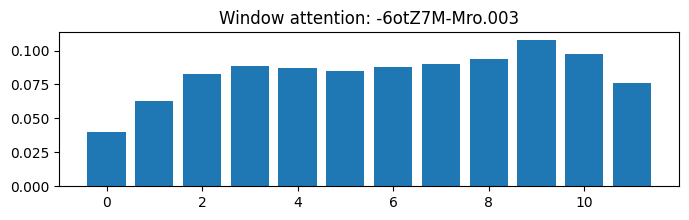

,trait,alpha_visual,alpha_audio
0,openness,0.607036,0.392964
1,conscientiousness,0.735910,0.264090
2,extraversion,0.673958,0.326042
3,agreeableness,0.707689,0.292310
4,neuroticism,0.607064,0.392936


video_id: -6otZ7M-Mro.005


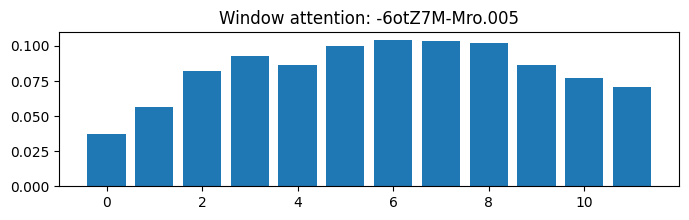

,trait,alpha_visual,alpha_audio
0,openness,0.617602,0.382398
1,conscientiousness,0.734080,0.265920
2,extraversion,0.689119,0.310881
3,agreeableness,0.724645,0.275355
4,neuroticism,0.612239,0.387761


video_id: -8asrRvfJWA.001


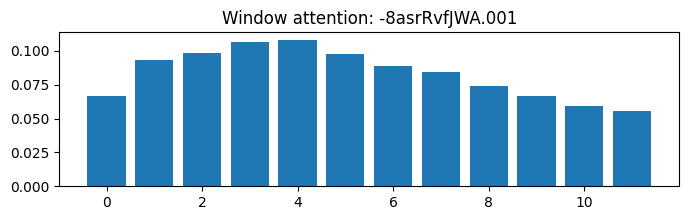

,trait,alpha_visual,alpha_audio
0,openness,0.649339,0.350661
1,conscientiousness,0.728396,0.271604
2,extraversion,0.745627,0.254373
3,agreeableness,0.656523,0.343477
4,neuroticism,0.629797,0.370203


In [ ]:
@torch.no_grad()
def inspect_attention_and_fusion(model, loader, n_examples=3):
    model.eval()
    shown = 0
    for batch in loader:
        batch_cpu = batch
        batch = move_batch_to_device(batch, DEVICE)
        out = model(batch)

        window_attn = out["vis_info"]["window_attn"].detach().cpu().numpy()
        alpha_v = out["fusion_info"]["alpha_v"].detach().cpu().numpy()
        alpha_a = out["fusion_info"]["alpha_a"].detach().cpu().numpy()

        for i, vid in enumerate(batch_cpu["video_id"]):
            print("video_id:", vid)

            plt.figure(figsize=(8, 2))
            plt.title(f"Window attention: {vid}")
            plt.bar(np.arange(len(window_attn[i])), window_attn[i])
            plt.show()

            df = pd.DataFrame({
                "trait": cfg.trait_names,
                "alpha_visual": alpha_v[i],
                "alpha_audio": alpha_a[i],
            })
            display(df)

            shown += 1
            if shown >= n_examples:
                return

inspect_attention_and_fusion(model, val_loader, n_examples=3)

## Простая saliency-визуализация по градиенту

Это не замена полноценному анализу, но уже даёт интерпретируемый визуальный сигнал.

In [ ]:
def make_saliency_map(model, batch, sample_idx=0, trait_idx=0):
    model.eval()

    faces = batch["faces"].clone().detach()
    faces.requires_grad_(True)

    new_batch = {
        "video_id": batch["video_id"],
        "faces": faces.to(DEVICE),
        "face_scores": batch["face_scores"].to(DEVICE),
        "mel": batch["mel"].to(DEVICE),
        "prosody": batch["prosody"].to(DEVICE),
        "ege_maps": batch["ege_maps"].to(DEVICE),
        "target": batch["target"].to(DEVICE),
    }

    out = model(new_batch)
    score = out["pred"][sample_idx, trait_idx]
    model.zero_grad(set_to_none=True)
    score.backward()

    grads = faces.grad[sample_idx].abs().mean(dim=1)   # [W, K, H, W]
    sal = grads.cpu().numpy()

    return sal

# пример:
batch0 = next(iter(val_loader))
sal = make_saliency_map(model, batch0, sample_idx=0, trait_idx=2)
plt.figure(figsize=(10, 3))
for i in range(min(6, sal.shape[0])):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sal[i, 0], cmap="hot")
    plt.axis("off")
plt.show()

RuntimeError: cudnn RNN backward can only be called in training mode